# NBA Head-to-Head Predictions

This notebook combines:
1. **Baselines** — simple rule-based predictors for the NBA game-outcome task
2. **Models** — Random Forest, Extra Trees, and XGBoost classifiers, evaluated via walk-forward CV

Baseline accuracy functions and the walk-forward CV loop now live in `src/models.py` as importable, tested functions rather than being copy-pasted per model — see that file for the shared `walk_forward_cv()` implementation.

# Part 1: Baselines

## Setting: home team win = 1, home team loss = 0

## Two baseline models: 

1. Home team always wins. 
Accuracy: 57.46%

2. Teams with better records of the last 10 games win; if same record, then home team wins.
Accuracy: 62.02%


## Setup

In [50]:
import sys
sys.path.insert(0, '..')  # so `src` is importable from notebooks/

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

from sklearn.metrics import accuracy_score, roc_auc_score, log_loss
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier

from pygam import LogisticGAM, s
from functools import reduce
import operator

from scipy import stats
import plotly.graph_objects as go



from src.models import (
    walk_forward_cv, home_team_always_wins_accuracy, better_recent_record_accuracy,
)


In [2]:
# Load matchup-level dataset (rolling-window / record-based features)
prefix = "../data/processed/"
matchups = pd.read_csv(prefix + 'TeamStatisticsFrom2010RPMatchups.csv')


In [3]:
# Inspect the dataframe
matchups


,gameId,gameDate,season,win,home_teamId,home_teamName,home_rest_days,home_b2b,home_teamScore_roll10,home_fieldGoalsPercentage_roll10,...,reboundsOffensive_roll10_diff,reboundsDefensive_roll10_diff,assists_roll10_diff,turnovers_roll10_diff,steals_roll10_diff,blocks_roll10_diff,plusMinusPoints_roll10_diff,win_roll10_diff,rest_days_diff,b2b_diff
0,21000031,2010-10-30,2010,1,1610612737,Hawks,0.0,1,111.500000,0.519500,...,6.500000,13.500000,5.000000,4.500000,-5.000000,5.500000,38.000000,1.000000,-1.0,1
1,21000054,2010-11-03,2010,1,1610612737,Hawks,0.0,1,105.500000,0.474750,...,-0.500000,4.000000,6.250000,0.000000,0.750000,2.250000,17.750000,1.000000,0.0,0
2,21000090,2010-11-07,2010,0,1610612737,Hawks,1.0,0,104.833333,0.496500,...,-4.100000,4.033333,3.700000,-2.333333,-3.166667,1.700000,9.433333,0.600000,0.0,0
3,21000108,2010-11-10,2010,0,1610612737,Hawks,1.0,0,104.000000,0.499375,...,-1.000000,1.250000,6.625000,-0.500000,-1.000000,2.750000,5.250000,0.375000,1.0,-1
4,21000121,2010-11-12,2010,0,1610612737,Hawks,1.0,0,102.555556,0.498667,...,-0.819444,0.402778,-0.819444,-0.888889,-2.361111,0.694444,2.236111,0.041667,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20496,22501085,2026-03-29,2025,0,1610612766,Hornets,0.0,1,117.300000,0.463500,...,1.200000,-2.500000,1.400000,1.700000,1.000000,1.200000,5.600000,0.000000,-1.0,1
20497,22501114,2026-04-02,2025,1,1610612766,Hornets,1.0,0,118.700000,0.473400,...,-0.400000,3.300000,-0.800000,2.300000,-2.200000,-1.200000,9.800000,0.400000,0.0,0
20498,22501120,2026-04-03,2025,1,1610612766,Hornets,0.0,1,119.700000,0.479400,...,5.100000,2.600000,-8.700000,-0.200000,-0.100000,-0.700000,18.500000,0.400000,-1.0,1
20499,22501171,2026-04-10,2025,0,1610612766,Hornets,2.0,0,118.200000,0.476200,...,2.100000,1.500000,-5.800000,-2.500000,-3.500000,-3.000000,4.400000,0.000000,1.0,0


## Baseline 1: home team always wins
Simplest possible baseline — predict the home team wins every game.

In [4]:
# Per-season accuracy (= home win rate each season) via src.models.home_team_always_wins_accuracy
home_team_win_acc = home_team_always_wins_accuracy(matchups, start_year=2015, end_year=2026)
home_team_win_acc.round(4)


season
2015    0.5942
2016    0.5829
2017    0.5869
2018    0.5907
2019    0.5448
2020    0.5465
2021    0.5480
2022    0.5811
2023    0.5470
2024    0.5452
2025    0.5552
Name: home_team_win, dtype: float64

In [5]:
# Overall home win rate = accuracy of the "home team always wins" baseline, across all seasons combined
matchups['win'].mean()


np.float64(0.5745573386664066)

## Baseline 2: better recent record wins
Predict the team with the better record over its last 10 games wins; ties go to the home team.

In [6]:
# win_roll10_diff = (home team's last-10-game win pct) - (away team's last-10-game win pct)
matchups['win_roll10_diff'].describe()


count    20501.000000
mean        -0.003454
std          0.291555
min         -1.000000
25%         -0.200000
50%          0.000000
75%          0.200000
max          1.000000
Name: win_roll10_diff, dtype: float64

In [7]:
# Distribution of the raw diff values
matchups['win_roll10_diff'].value_counts()


win_roll10_diff
 0.000000    2845
-0.100000    1929
 0.100000    1871
-0.300000    1273
 0.300000    1262
             ... 
 0.144444       1
-0.071429       1
 0.033333       1
 0.050000       1
-0.550000       1
Name: count, Length: 95, dtype: int64

In [8]:
# Overall accuracy of the "better recent record wins" baseline, across all seasons combined
pred_win = (matchups['win_roll10_diff'] >= 0).astype(int)
print(f"Accuracy: {accuracy_score(matchups['win'], pred_win):.4f}")


Accuracy: 0.6202


In [9]:
# Per-season accuracy via src.models.better_recent_record_accuracy
better_last10_acc = better_recent_record_accuracy(
    matchups, diff_col='win_roll10_diff', start_year=2015, end_year=2026
)
better_last10_acc.round(4)


season
2015    0.6375
2016    0.6157
2017    0.6258
2018    0.6159
2019    0.6149
2020    0.5918
2021    0.6039
2022    0.5712
2023    0.6244
2024    0.6327
2025    0.6407
Name: better_last10_win, dtype: float64

# Part 2: Models

## Load data

In [10]:
# Precomputed matchup-level datasets:
#   matchups    - raw home/away diff features
#   matchupsEWM - EWM-smoothed (halflife=3) diff features
matchups = pd.read_csv(prefix + 'TeamStatisticsFrom2010RegMatchups.csv')
matchupsEWM = pd.read_csv(prefix + 'TeamStatisticsFrom2010RegEWMMatchups.csv')


## Data exploration
Quick sanity checks on the two datasets before modeling.

In [11]:
# Peek at available columns for the EWM dataset
matchupsEWM.columns


Index(['gameId', 'gameDate', 'season', 'win', 'home_teamId', 'home_teamName',
       'home_rest_days', 'home_b2b', 'home_teamScore_ewm3',
       'home_fieldGoalsPercentage_ewm3', 'home_threePointersPercentage_ewm3',
       'home_freeThrowsPercentage_ewm3', 'home_reboundsOffensive_ewm3',
       'home_reboundsDefensive_ewm3', 'home_assists_ewm3',
       'home_turnovers_ewm3', 'home_steals_ewm3', 'home_blocks_ewm3',
       'home_plusMinusPoints_ewm3', 'home_win_ewm3', 'away_teamId',
       'away_teamName', 'away_rest_days', 'away_b2b', 'away_teamScore_ewm3',
       'away_fieldGoalsPercentage_ewm3', 'away_threePointersPercentage_ewm3',
       'away_freeThrowsPercentage_ewm3', 'away_reboundsOffensive_ewm3',
       'away_reboundsDefensive_ewm3', 'away_assists_ewm3',
       'away_turnovers_ewm3', 'away_steals_ewm3', 'away_blocks_ewm3',
       'away_plusMinusPoints_ewm3', 'away_win_ewm3', 'teamScore_ewm3_diff',
       'fieldGoalsPercentage_ewm3_diff', 'threePointersPercentage_ewm3_diff',
     

In [12]:
# Engineered home-minus-away 'diff' features for the EWM dataset
features_diff_ewm = [c for c in matchupsEWM.columns if c.endswith('_diff')]
features_diff_ewm


['teamScore_ewm3_diff',
 'fieldGoalsPercentage_ewm3_diff',
 'threePointersPercentage_ewm3_diff',
 'freeThrowsPercentage_ewm3_diff',
 'reboundsOffensive_ewm3_diff',
 'reboundsDefensive_ewm3_diff',
 'assists_ewm3_diff',
 'turnovers_ewm3_diff',
 'steals_ewm3_diff',
 'blocks_ewm3_diff',
 'plusMinusPoints_ewm3_diff',
 'win_ewm3_diff',
 'rest_days_diff',
 'b2b_diff']

In [13]:
# Engineered home-minus-away 'diff' features for the raw dataset
features_diff = [c for c in matchups.columns if c.endswith('_diff')]
features_diff


['teamScore_roll10_diff',
 'fieldGoalsPercentage_roll10_diff',
 'threePointersPercentage_roll10_diff',
 'freeThrowsPercentage_roll10_diff',
 'reboundsOffensive_roll10_diff',
 'reboundsDefensive_roll10_diff',
 'assists_roll10_diff',
 'turnovers_roll10_diff',
 'steals_roll10_diff',
 'blocks_roll10_diff',
 'plusMinusPoints_roll10_diff',
 'win_roll10_diff',
 'rest_days_diff',
 'b2b_diff']

# Train on 2010-2024, keep 2025 as the test dataset.
## Cross validate from 2015 to 2025 using the rolling 5 years for training


### Random Forest

In [16]:
# for repeatable results and reasonable comparison between models
RANDOM_STATE = 216

In [17]:
# Walk-forward validation via src.models.walk_forward_cv: for each season i in
# 2015-2025, train on the trailing 5 seasons (i-5 .. i-1) and validate on season i
# itself. This avoids lookahead bias (no future data used to predict the past).
results_rf = walk_forward_cv(
    matchups, features_diff,
    model_factory=lambda: RandomForestClassifier(
        n_estimators=500,       # number of trees in ensemble
        max_depth=10,           # max_depth of each tree
        min_samples_leaf=5,
        max_features=3,         # default would be round(sqrt(14)) = 4; using 3 for slightly more tree diversity
        bootstrap=True,         # sampling with replacement
        max_samples=500,        # number of training samples selected with replacement to build tree
        random_state=RANDOM_STATE,       # for consistency
    ),
    train_window=5, start_year=2015, end_year=2026,
)

# Save this model's per-season accuracy under its own name for the final summary table
rf_rolling10_acc = results_rf['accuracy'].rename('RandomForest_rolling10')

results_rf


,accuracy,teamScore_roll10_diff,fieldGoalsPercentage_roll10_diff,threePointersPercentage_roll10_diff,freeThrowsPercentage_roll10_diff,reboundsOffensive_roll10_diff,reboundsDefensive_roll10_diff,assists_roll10_diff,turnovers_roll10_diff,steals_roll10_diff,blocks_roll10_diff,plusMinusPoints_roll10_diff,win_roll10_diff,rest_days_diff,b2b_diff
season,,,,,,,,,,,,,,,
2015,0.643089,0.080113,0.093040,0.075788,0.073983,0.068761,0.075699,0.066085,0.064260,0.063242,0.060937,0.154412,0.094942,0.017633,0.011107
2016,0.630081,0.083924,0.094697,0.079681,0.070764,0.063001,0.071804,0.072153,0.065199,0.063063,0.061525,0.150981,0.092825,0.018933,0.011450
2017,0.621138,0.083845,0.096387,0.080527,0.073480,0.066396,0.070772,0.073286,0.063336,0.061904,0.063212,0.152209,0.086718,0.018902,0.009026
2018,0.637398,0.086099,0.092209,0.075773,0.071280,0.066646,0.065693,0.075958,0.064243,0.063169,0.062945,0.153223,0.094730,0.017523,0.010508
2019,0.612637,0.084396,0.087188,0.080969,0.075494,0.064469,0.074486,0.073660,0.066902,0.064898,0.064612,0.151515,0.084478,0.017739,0.009195
2020,0.600926,0.086771,0.089565,0.077718,0.076030,0.064153,0.077533,0.074974,0.069904,0.062488,0.066249,0.143777,0.083680,0.017529,0.009631
2021,0.618699,0.088115,0.091817,0.080361,0.080953,0.068476,0.073759,0.074531,0.068140,0.061084,0.064931,0.141339,0.077298,0.018804,0.010392
2022,0.595122,0.090186,0.090681,0.078788,0.078380,0.067820,0.079592,0.071772,0.070304,0.065582,0.063511,0.138477,0.079945,0.016401,0.008562
2023,0.639024,0.083201,0.088706,0.083517,0.083381,0.068706,0.080589,0.078888,0.073542,0.064748,0.064404,0.130875,0.070651,0.018039,0.010754


### Extra Trees Classifier

In [18]:
# Same walk-forward CV as Random Forest above, using ExtraTreesClassifier
# (no bootstrap sampling, more randomized splits).
results_et = walk_forward_cv(
    matchups, features_diff,
    model_factory=lambda: ExtraTreesClassifier(
        n_estimators=500,
        max_depth=10,
        min_samples_leaf=5,
        max_features=3,
        bootstrap=False,  # Extra Trees default is no bootstrap
        random_state=RANDOM_STATE,
    ),
    train_window=5, start_year=2015, end_year=2026,
)

# Save this model's per-season accuracy under its own name for the final summary table
et_rolling10_acc = results_et['accuracy'].rename('ExtraTree_rolling10')

results_et


,accuracy,teamScore_roll10_diff,fieldGoalsPercentage_roll10_diff,threePointersPercentage_roll10_diff,freeThrowsPercentage_roll10_diff,reboundsOffensive_roll10_diff,reboundsDefensive_roll10_diff,assists_roll10_diff,turnovers_roll10_diff,steals_roll10_diff,blocks_roll10_diff,plusMinusPoints_roll10_diff,win_roll10_diff,rest_days_diff,b2b_diff
season,,,,,,,,,,,,,,,
2015,0.650407,0.065735,0.093543,0.030666,0.024854,0.025661,0.045721,0.033146,0.023587,0.030739,0.028595,0.287958,0.267180,0.016985,0.025631
2016,0.630894,0.089642,0.104519,0.039638,0.021587,0.021296,0.039794,0.038370,0.021492,0.026913,0.028185,0.263135,0.262066,0.017234,0.026129
2017,0.634959,0.095470,0.102252,0.040597,0.024611,0.023827,0.031664,0.049782,0.023439,0.025206,0.026388,0.269868,0.241027,0.017834,0.028035
2018,0.634959,0.097945,0.093967,0.039646,0.024124,0.021711,0.031367,0.052717,0.024124,0.023272,0.029060,0.260844,0.255095,0.016452,0.029676
2019,0.618132,0.100805,0.085966,0.039986,0.022495,0.019963,0.036582,0.055146,0.025071,0.025336,0.031011,0.275036,0.236631,0.017705,0.028268
2020,0.598148,0.094486,0.089882,0.036962,0.023293,0.021322,0.044013,0.048795,0.030933,0.024237,0.040339,0.260083,0.235759,0.018169,0.031728
2021,0.627642,0.091733,0.091133,0.043112,0.030884,0.023656,0.041690,0.038033,0.030116,0.026371,0.036967,0.253689,0.240333,0.017104,0.035179
2022,0.605691,0.093585,0.083924,0.036689,0.035510,0.024217,0.055173,0.035542,0.035370,0.027242,0.037140,0.243534,0.236737,0.020645,0.034693
2023,0.630894,0.073479,0.076900,0.047387,0.043008,0.025042,0.058430,0.045739,0.045506,0.027073,0.032274,0.250068,0.211362,0.023770,0.039962


### XGBoost Classifier

In [19]:
results_xgb = walk_forward_cv(
    matchups, features_diff,
    model_factory=lambda: XGBClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, eval_metric='logloss', random_state=RANDOM_STATE,
    ),
    train_window=5, start_year=2015, end_year=2026,
)

xgb_acc = results_xgb['accuracy'].rename('XGBoost')
results_xgb

,accuracy,teamScore_roll10_diff,fieldGoalsPercentage_roll10_diff,threePointersPercentage_roll10_diff,freeThrowsPercentage_roll10_diff,reboundsOffensive_roll10_diff,reboundsDefensive_roll10_diff,assists_roll10_diff,turnovers_roll10_diff,steals_roll10_diff,blocks_roll10_diff,plusMinusPoints_roll10_diff,win_roll10_diff,rest_days_diff,b2b_diff
season,,,,,,,,,,,,,,,
2015,0.635772,0.050664,0.056053,0.053883,0.051325,0.053378,0.047649,0.052215,0.047892,0.052794,0.052947,0.196079,0.175316,0.046991,0.062814
2016,0.633333,0.050579,0.055488,0.047378,0.051602,0.045315,0.048084,0.050794,0.046322,0.049230,0.050727,0.212065,0.191968,0.051419,0.049028
2017,0.614634,0.052862,0.056009,0.048481,0.049983,0.046970,0.045428,0.048518,0.043896,0.048883,0.046220,0.216304,0.197002,0.050091,0.049354
2018,0.621138,0.056685,0.052585,0.052574,0.051638,0.051161,0.047768,0.052461,0.050646,0.051177,0.046574,0.209602,0.169034,0.051787,0.056307
2019,0.618132,0.057864,0.052803,0.051928,0.055060,0.048097,0.048594,0.051324,0.048574,0.051381,0.048808,0.224178,0.153398,0.054082,0.053911
2020,0.599074,0.058391,0.057330,0.049147,0.049147,0.049940,0.047401,0.054289,0.051188,0.050153,0.052002,0.203942,0.164988,0.055639,0.056444
2021,0.617073,0.059259,0.059614,0.055762,0.057125,0.055967,0.053004,0.048737,0.049983,0.051364,0.050847,0.196534,0.138546,0.057297,0.065963
2022,0.581301,0.056280,0.058029,0.054133,0.055284,0.050477,0.048994,0.052672,0.052242,0.051034,0.052302,0.201442,0.153253,0.054071,0.059788
2023,0.640650,0.061505,0.059476,0.057301,0.058910,0.050186,0.053810,0.055695,0.054750,0.053164,0.052444,0.177967,0.135719,0.065111,0.063962


### Logistic Regression

In [23]:
results_lr = walk_forward_cv(
    matchups, features_diff,
    model_factory=lambda: make_pipeline(
        StandardScaler(),
        LogisticRegression(l1_ratio=1, solver='liblinear', C=1.0, random_state=RANDOM_STATE),
    ),
    train_window=5, start_year=2015, end_year=2026,
)

lr_acc = results_lr['accuracy'].rename('LogisticRegression')
lr_acc

season
2015    0.652033
2016    0.633333
2017    0.628455
2018    0.645528
2019    0.610806
2020    0.601852
2021    0.622764
2022    0.604065
2023    0.636585
2024    0.658776
2025    0.653940
Name: LogisticRegression, dtype: float64

### Naive Bayes

In [24]:
results_nb = walk_forward_cv(
    matchups, features_diff,
    model_factory=lambda: GaussianNB(),
    train_window=5, start_year=2015, end_year=2026,
)

nb_acc = results_nb['accuracy'].rename('NaiveBayes')
results_nb

,accuracy
season,
2015,0.656098
2016,0.612195
2017,0.622764
2018,0.625203
2019,0.613553
2020,0.612037
2021,0.619512
2022,0.586179
2023,0.642276


### GAM

In [25]:
def make_gam(n_features):
    terms = reduce(operator.add, [s(i) for i in range(n_features)])
    return LogisticGAM(terms)

In [26]:
results_gam = walk_forward_cv(
    matchups, features_diff,
    model_factory=lambda: make_gam(len(features_diff)),
    train_window=5, start_year=2015, end_year=2026,
)

gam_acc = results_gam['accuracy'].rename('GAM')
results_gam

,accuracy
season,
2015,0.639837
2016,0.632520
2017,0.614634
2018,0.629268
2019,0.611722
2020,0.592593
2021,0.617886
2022,0.594309
2023,0.628455


## Rolling-window CV with EWM (halflife=3) features
Repeats the same walk-forward validation strategy as above, but using the EWM-smoothed feature set (`matchupsEWM` / `features_diff_ewm`).

### Random Forest (EWM features)

In [38]:
results_rf_ewm = walk_forward_cv(
    matchupsEWM, features_diff_ewm,
    model_factory=lambda: RandomForestClassifier(
        n_estimators=500, max_depth=10, min_samples_leaf=5, max_features=3,
        bootstrap=True, max_samples=500, random_state=RANDOM_STATE,
    ),
    train_window=5, start_year=2015, end_year=2026,
)

rf_ewm_acc = results_rf_ewm['accuracy'].rename('RandomForest_ewm')
results_rf_ewm


,accuracy,teamScore_ewm3_diff,fieldGoalsPercentage_ewm3_diff,threePointersPercentage_ewm3_diff,freeThrowsPercentage_ewm3_diff,reboundsOffensive_ewm3_diff,reboundsDefensive_ewm3_diff,assists_ewm3_diff,turnovers_ewm3_diff,steals_ewm3_diff,blocks_ewm3_diff,plusMinusPoints_ewm3_diff,win_ewm3_diff,rest_days_diff,b2b_diff
season,,,,,,,,,,,,,,,
2015,0.634959,0.077216,0.082389,0.071666,0.066427,0.062425,0.074016,0.069762,0.065748,0.066059,0.064766,0.141499,0.132993,0.014368,0.010667
2016,0.617073,0.079110,0.087451,0.072434,0.065036,0.064751,0.071751,0.070760,0.063704,0.066009,0.067764,0.137556,0.128845,0.015236,0.009592
2017,0.626016,0.080173,0.089231,0.074221,0.064985,0.064411,0.069743,0.073966,0.062544,0.063705,0.066802,0.137732,0.127083,0.016988,0.008416
2018,0.634146,0.080795,0.085050,0.071880,0.066304,0.068333,0.068311,0.074415,0.068339,0.060334,0.064961,0.137826,0.128693,0.016219,0.008538
2019,0.619048,0.085297,0.081260,0.070587,0.067851,0.064554,0.069324,0.074942,0.067448,0.067628,0.066692,0.144356,0.115888,0.015221,0.008951
2020,0.605556,0.078572,0.078876,0.070872,0.067344,0.068917,0.075048,0.075206,0.070811,0.066079,0.071383,0.134560,0.120278,0.014087,0.007966
2021,0.621951,0.081534,0.079432,0.072698,0.068631,0.066672,0.074446,0.070371,0.073225,0.071800,0.071917,0.128707,0.116446,0.015506,0.008614
2022,0.608130,0.078901,0.076367,0.069900,0.073322,0.066146,0.077692,0.067716,0.071727,0.068609,0.072252,0.131744,0.120972,0.015115,0.009536
2023,0.626016,0.076970,0.077006,0.072876,0.076228,0.070285,0.079625,0.076625,0.075046,0.068880,0.065623,0.123366,0.111884,0.015973,0.009614


### Extra Trees Classifier (EWM features)

In [39]:
results_et_ewm = walk_forward_cv(
    matchupsEWM, features_diff_ewm,
    model_factory=lambda: ExtraTreesClassifier(
        n_estimators=500, max_depth=10, min_samples_leaf=5, max_features=3,
        bootstrap=False, random_state=RANDOM_STATE,
    ),
    train_window=5, start_year=2015, end_year=2026,
)

et_ewm_acc = results_et_ewm['accuracy'].rename('ExtraTree_ewm')
results_et_ewm


,accuracy,teamScore_ewm3_diff,fieldGoalsPercentage_ewm3_diff,threePointersPercentage_ewm3_diff,freeThrowsPercentage_ewm3_diff,reboundsOffensive_ewm3_diff,reboundsDefensive_ewm3_diff,assists_ewm3_diff,turnovers_ewm3_diff,steals_ewm3_diff,blocks_ewm3_diff,plusMinusPoints_ewm3_diff,win_ewm3_diff,rest_days_diff,b2b_diff
season,,,,,,,,,,,,,,,
2015,0.640650,0.073876,0.096559,0.033084,0.026835,0.023519,0.044951,0.035793,0.023905,0.027603,0.025987,0.285183,0.261257,0.016839,0.024610
2016,0.623577,0.089942,0.098843,0.042019,0.024809,0.021421,0.039868,0.039161,0.021248,0.029338,0.027624,0.278774,0.241081,0.018470,0.027404
2017,0.630894,0.088694,0.102788,0.038259,0.026449,0.023004,0.030014,0.048038,0.023964,0.029447,0.025518,0.271600,0.245622,0.018477,0.028125
2018,0.629268,0.097208,0.091403,0.041063,0.024400,0.021911,0.028446,0.051843,0.027533,0.026126,0.030039,0.262384,0.247711,0.017528,0.032405
2019,0.614469,0.101591,0.078652,0.039950,0.026791,0.020797,0.032459,0.053978,0.027732,0.029591,0.032377,0.279842,0.228619,0.018104,0.029518
2020,0.593519,0.088602,0.075364,0.035543,0.026054,0.023092,0.038428,0.050030,0.035760,0.030337,0.041236,0.268177,0.231763,0.019880,0.035733
2021,0.624390,0.086236,0.087496,0.041598,0.030873,0.024649,0.038637,0.039720,0.034494,0.030729,0.039976,0.262517,0.222657,0.020254,0.040163
2022,0.613821,0.089179,0.071892,0.036661,0.033447,0.024922,0.049940,0.034495,0.033794,0.031885,0.042974,0.260678,0.229908,0.021832,0.038393
2023,0.630081,0.074720,0.065207,0.042971,0.041013,0.027310,0.062120,0.040204,0.042420,0.031219,0.035379,0.258475,0.212054,0.024378,0.042528


### XGBoost (EWM features, rolling CV)

In [40]:
results_xgb_ewm = walk_forward_cv(
    matchupsEWM, features_diff_ewm,
    model_factory=lambda: XGBClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, eval_metric='logloss', random_state=RANDOM_STATE,
    ),
    train_window=5, start_year=2015, end_year=2026,
)

xgb_ewm_acc = results_xgb_ewm['accuracy'].rename('XGBoost_ewm')
results_xgb_ewm


,accuracy,teamScore_ewm3_diff,fieldGoalsPercentage_ewm3_diff,threePointersPercentage_ewm3_diff,freeThrowsPercentage_ewm3_diff,reboundsOffensive_ewm3_diff,reboundsDefensive_ewm3_diff,assists_ewm3_diff,turnovers_ewm3_diff,steals_ewm3_diff,blocks_ewm3_diff,plusMinusPoints_ewm3_diff,win_ewm3_diff,rest_days_diff,b2b_diff
season,,,,,,,,,,,,,,,
2015,0.636585,0.056072,0.061591,0.057519,0.057484,0.052850,0.054275,0.054181,0.053170,0.052378,0.053767,0.223850,0.110809,0.060479,0.051575
2016,0.606504,0.056841,0.063224,0.054536,0.054213,0.049836,0.053924,0.053337,0.053172,0.054308,0.057340,0.215879,0.111628,0.058960,0.062801
2017,0.626016,0.055674,0.062199,0.053186,0.052618,0.054251,0.056777,0.056081,0.051280,0.053620,0.058119,0.223349,0.105042,0.060162,0.057642
2018,0.619512,0.056348,0.058043,0.052641,0.052833,0.053892,0.056978,0.056836,0.050842,0.053567,0.053486,0.217176,0.111472,0.057040,0.068845
2019,0.620879,0.061506,0.057598,0.052466,0.057629,0.052529,0.053524,0.056054,0.051720,0.054631,0.054650,0.225643,0.103687,0.048775,0.069588
2020,0.603704,0.061337,0.057291,0.058316,0.055658,0.055581,0.056176,0.056850,0.054946,0.057391,0.058006,0.207013,0.102739,0.052419,0.066279
2021,0.626016,0.062354,0.061532,0.056536,0.059344,0.055433,0.055644,0.057334,0.057968,0.052151,0.058816,0.178034,0.110803,0.053295,0.080757
2022,0.582114,0.057052,0.061117,0.060057,0.056777,0.055441,0.056249,0.060351,0.058166,0.059798,0.057887,0.181718,0.105826,0.057076,0.072486
2023,0.627642,0.062469,0.062841,0.058045,0.060308,0.059892,0.059905,0.060379,0.061670,0.059839,0.057901,0.179791,0.092373,0.063754,0.060833


### Logistic Regression

In [43]:
results_lr_ewm = walk_forward_cv(
    matchupsEWM, features_diff_ewm,
    model_factory=lambda: make_pipeline(
        StandardScaler(),
        LogisticRegression(l1_ratio=1, solver='liblinear', C=1.0, random_state=RANDOM_STATE),
    ),
    train_window=5, start_year=2015, end_year=2026,
)

lr_ewm_acc = results_lr['accuracy'].rename('LogisticRegression_ewm')
lr_ewm_acc

season
2015    0.652033
2016    0.633333
2017    0.628455
2018    0.645528
2019    0.610806
2020    0.601852
2021    0.622764
2022    0.604065
2023    0.636585
2024    0.658776
2025    0.653940
Name: LogisticRegression_ewm, dtype: float64

### Naive Bayes

In [44]:
results_nb_ewm = walk_forward_cv(
    matchupsEWM, features_diff_ewm,
    model_factory=lambda: GaussianNB(),
    train_window=5, start_year=2015, end_year=2026,
)

nb_ewm_acc = results_nb_ewm['accuracy'].rename('NaiveBayes_ewm')
results_nb_ewm

,accuracy
season,
2015,0.639837
2016,0.617886
2017,0.611382
2018,0.620325
2019,0.625458
2020,0.600000
2021,0.616260
2022,0.577236
2023,0.626829


### GAM

In [45]:
results_gam_ewm = walk_forward_cv(
    matchupsEWM, features_diff_ewm,
    model_factory=lambda: make_gam(len(features_diff)),
    train_window=5, start_year=2015, end_year=2026,
)

gam_ewm_acc = results_gam_ewm['accuracy'].rename('GAM_ewm')
results_gam_ewm

,accuracy
season,
2015,0.631707
2016,0.612195
2017,0.622764
2018,0.638211
2019,0.611722
2020,0.594444
2021,0.633333
2022,0.591870
2023,0.621951


# Part 3: Combined Accuracy Summary (2015-2025)

One row per season, one column per model, pulling together the per-season accuracy Series saved throughout the notebook above.

**Note:** the raw-diff XGBoost baseline (single chronological 80/20 holdout, see Part 2) only produces one overall accuracy number, not a per-season breakdown, so it isn't included as a column here. Only the EWM walk-forward XGBoost model (which evaluates one season at a time like RF/ExtraTrees) fits this table.

In [32]:
# Combine every per-season accuracy Series saved above into one summary table
rolling_accuracy_df = pd.concat(
    [
        home_team_win_acc,
        better_last10_acc,
        rf_rolling10_acc,
        et_rolling10_acc,
        xgb_acc,
        lr_acc,
        nb_acc,
        gam_acc,
    ],
    axis=1
)
rolling_accuracy_df.index.name = 'year'

# Append mean and std summary rows for each model column
summary_rows = rolling_accuracy_df.agg(['mean', 'std'])
rolling_accuracy_df = pd.concat([rolling_accuracy_df, summary_rows])
rolling_accuracy_df.index.name = 'year'

rolling_accuracy_df.round(4)


,home_team_win,better_last10_win,RandomForest_rolling10,ExtraTree_rolling10,XGBoost,LogisticRegression,NaiveBayes,GAM
year,,,,,,,,
2015,0.5942,0.6375,0.6431,0.6504,0.6358,0.6520,0.6561,0.6398
2016,0.5829,0.6157,0.6301,0.6309,0.6333,0.6333,0.6122,0.6325
2017,0.5869,0.6258,0.6211,0.6350,0.6146,0.6285,0.6228,0.6146
2018,0.5907,0.6159,0.6374,0.6350,0.6211,0.6455,0.6252,0.6293
2019,0.5448,0.6149,0.6126,0.6181,0.6181,0.6108,0.6136,0.6117
2020,0.5465,0.5918,0.6009,0.5981,0.5991,0.6019,0.6120,0.5926
2021,0.5480,0.6039,0.6187,0.6276,0.6171,0.6228,0.6195,0.6179
2022,0.5811,0.5712,0.5951,0.6057,0.5813,0.6041,0.5862,0.5943
2023,0.5470,0.6244,0.6390,0.6309,0.6407,0.6366,0.6423,0.6285


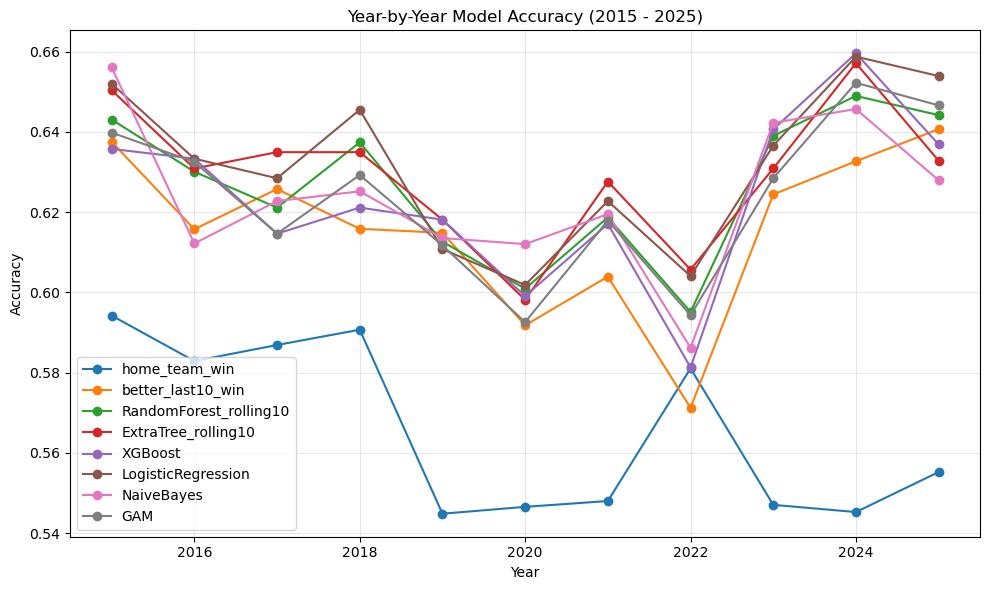

In [33]:
# Exclude the mean/std summary rows, keep only the year-indexed rows
plot_rolling = rolling_accuracy_df.drop(index=['mean', 'std'])

fig, ax = plt.subplots(figsize=(10, 6))

for col in plot_rolling.columns:
    line = ax.plot(plot_rolling.index, plot_rolling[col], marker='o', label=col)[0]


ax.set_xlabel('Year')
ax.set_ylabel('Accuracy')
ax.set_title('Year-by-Year Model Accuracy (2015 - 2025)')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
# plt.xticks(plot_df.index, rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
fig = go.Figure()

for col in plot_rolling.columns:
    fig.add_trace(go.Scatter(
        x=plot_rolling.index,
        y=plot_rolling[col],
        mode='lines+markers',
        name=col,
        hovertemplate='%{y:.4f}<extra>' + col + '</extra>'
    ))

fig.update_layout(
    title='Year-by-Year Model Accuracy (2015–2025)',
    xaxis_title='Year',
    yaxis_title='Accuracy',
    hovermode='x unified',
    legend_title='Model',
    template='plotly_white',
    width=900,
    height=550
)

fig.show()

In [53]:
def compare_models_to_best(accuracy_df, exclude_index=('mean', 'std')):
    """Rank models by mean accuracy, then run a paired t-test between the
    top model and every other model, using each season as a paired observation.
    Returns (ranking, comparison_df)."""
    df = accuracy_df[~accuracy_df.index.isin(exclude_index)]

    ranking = df.mean().sort_values(ascending=False)
    best_model = ranking.index[0]
    best_series = df[best_model]

    rows = []
    for col in df.columns:
        if col == best_model:
            continue
        diff = best_series - df[col]
        t_stat, p_value = stats.ttest_rel(best_series, df[col])
        rows.append({
            'model': col,
            'mean_diff': diff.mean(),
            f'{best_model}_wins': int((diff > 0).sum()),
            'n_seasons': len(diff),
            't_stat': t_stat,
            'p_value': p_value,
        })

    comparison_df = pd.DataFrame(rows).set_index('model').sort_values('p_value')
    return best_model, ranking, comparison_df




In [54]:
best_model, ranking, comparison_df = compare_models_to_best(rolling_accuracy_df)

print(f"Best model by mean accuracy: {best_model}\n")
print("Mean accuracy ranking:")
print(ranking.round(4))
print(f"\nPaired comparisons vs. {best_model}:")
comparison_df.round(4)

Best model by mean accuracy: LogisticRegression

Mean accuracy ranking:
LogisticRegression        0.6316
ExtraTree_rolling10       0.6292
RandomForest_rolling10    0.6265
NaiveBayes                0.6240
GAM                       0.6236
XGBoost                   0.6234
better_last10_win         0.6159
home_team_win             0.5657
dtype: float64

Paired comparisons vs. LogisticRegression:


,mean_diff,LogisticRegression_wins,n_seasons,t_stat,p_value
model,,,,,
home_team_win,0.0660,11,11,8.2947,0.0000
GAM,0.0080,10,11,5.1283,0.0004
better_last10_win,0.0158,10,11,4.7357,0.0008
RandomForest_rolling10,0.0052,9,11,3.7050,0.0041
XGBoost,0.0082,7,11,2.4669,0.0333
NaiveBayes,0.0077,7,11,2.0322,0.0696
ExtraTree_rolling10,0.0024,7,11,0.9714,0.3543


In [46]:
# Combine every per-season accuracy Series saved above into one summary table
ewm_accuracy_df = pd.concat(
    [
        home_team_win_acc,
        better_last10_acc,
        rf_ewm_acc,
        et_ewm_acc,
        xgb_ewm_acc,
        lr_ewm_acc,
        nb_ewm_acc,
        gam_ewm_acc,
    ],
    axis=1
)
ewm_accuracy_df.index.name = 'year'

# Append mean and std summary rows for each model column
summary_rows = ewm_accuracy_df.agg(['mean', 'std'])
ewm_accuracy_df = pd.concat([ewm_accuracy_df, summary_rows])
ewm_accuracy_df.index.name = 'year'

ewm_accuracy_df.round(4)


,home_team_win,better_last10_win,RandomForest_ewm,ExtraTree_ewm,XGBoost_ewm,LogisticRegression_ewm,NaiveBayes_ewm,GAM_ewm
year,,,,,,,,
2015,0.5942,0.6375,0.6350,0.6407,0.6366,0.6520,0.6398,0.6317
2016,0.5829,0.6157,0.6171,0.6236,0.6065,0.6333,0.6179,0.6122
2017,0.5869,0.6258,0.6260,0.6309,0.6260,0.6285,0.6114,0.6228
2018,0.5907,0.6159,0.6341,0.6293,0.6195,0.6455,0.6203,0.6382
2019,0.5448,0.6149,0.6190,0.6145,0.6209,0.6108,0.6255,0.6117
2020,0.5465,0.5918,0.6056,0.5935,0.6037,0.6019,0.6000,0.5944
2021,0.5480,0.6039,0.6220,0.6244,0.6260,0.6228,0.6163,0.6333
2022,0.5811,0.5712,0.6081,0.6138,0.5821,0.6041,0.5772,0.5919
2023,0.5470,0.6244,0.6260,0.6301,0.6276,0.6366,0.6268,0.6220


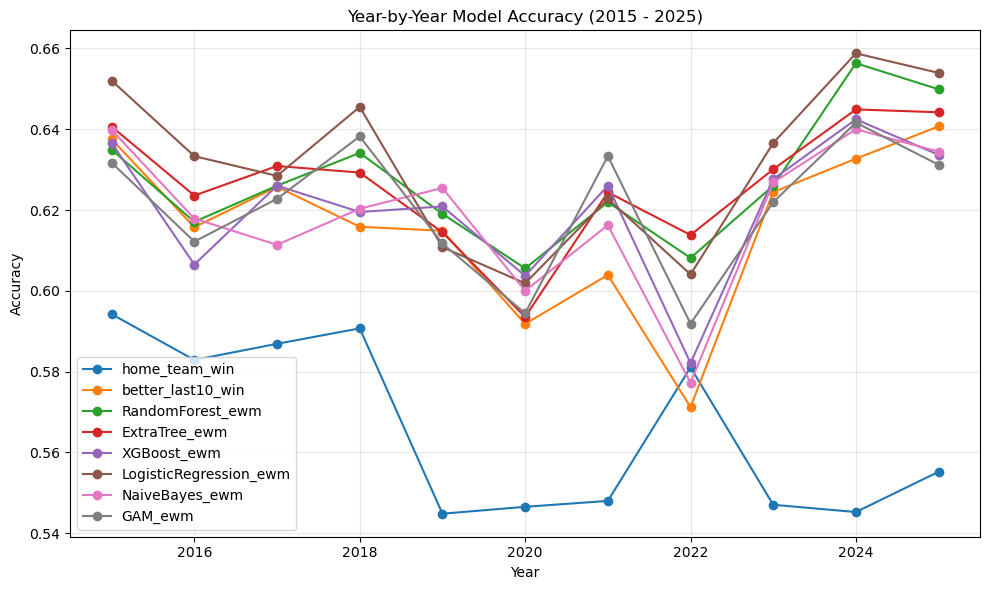

In [47]:
# Exclude the mean/std summary rows, keep only the year-indexed rows
plot_ewm = ewm_accuracy_df.drop(index=['mean', 'std'])

fig, ax = plt.subplots(figsize=(10, 6))

for col in plot_ewm.columns:
    line = ax.plot(plot_ewm.index, plot_ewm[col], marker='o', label=col)[0]


ax.set_xlabel('Year')
ax.set_ylabel('Accuracy')
ax.set_title('Year-by-Year Model Accuracy (2015 - 2025)')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
# plt.xticks(plot_df.index, rotation=45)
plt.tight_layout()
plt.show()

In [55]:
ewm_best_model, ewm_ranking, ewm_comparison_df = compare_models_to_best(ewm_accuracy_df)

print(f"Best model by mean accuracy: {ewm_best_model}\n")
print("Mean accuracy ranking:")
print(ranking.round(4))
print(f"\nPaired comparisons vs. {ewm_best_model}:")
ewm_comparison_df.round(4)

Best model by mean accuracy: LogisticRegression_ewm

Mean accuracy ranking:
LogisticRegression        0.6316
ExtraTree_rolling10       0.6292
RandomForest_rolling10    0.6265
NaiveBayes                0.6240
GAM                       0.6236
XGBoost                   0.6234
better_last10_win         0.6159
home_team_win             0.5657
dtype: float64

Paired comparisons vs. LogisticRegression_ewm:


,mean_diff,LogisticRegression_ewm_wins,n_seasons,t_stat,p_value
model,,,,,
home_team_win,0.0660,11,11,8.2947,0.0000
better_last10_win,0.0158,10,11,4.7357,0.0008
NaiveBayes_ewm,0.0126,10,11,3.5559,0.0052
GAM_ewm,0.0106,9,11,3.4615,0.0061
XGBoost_ewm,0.0112,8,11,2.9155,0.0154
ExtraTree_ewm,0.0053,7,11,2.1100,0.0610
RandomForest_ewm,0.0045,8,11,1.7599,0.1089
